<a href="https://colab.research.google.com/github/princesapkota/worksheets6thsem/blob/main/Worksheet_5_CNN_FruitClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worksheet 5 - End to End Image Classification using CNN
## 6CS012 - Artificial Intelligence and Machine Learning

In this notebook, I will build and train a CNN to classify 6 types of Amazon fruits using TensorFlow and Keras.

In [1]:
# importing all the libraries we need
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

# checking tensorflow version just to be sure
print(f"TensorFlow version: {tf.__version__}")
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: False


## Task 1: Data Understanding and Visualization

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset extracted!")
print("Contents:", os.listdir('/content/FruitinAmazon'))

Dataset extracted!
Contents: ['test', 'train']


In [4]:
# setting up the paths to our dataset
# the dataset has a train folder and a test folder
# each folder has 6 subfolders - one for each fruit class
train_dir = '/content/FruitinAmazon/train'
test_dir = '/content/FruitinAmazon/test'

# lets see what classes we have
classes = sorted(os.listdir(train_dir))
print(f"Fruit classes: {classes}")
print(f"Number of classes: {len(classes)}")

# counting how many images in each class
for cls in classes:
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    test_count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"  {cls}: {train_count} train, {test_count} test images")

Fruit classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
  acai: 15 train, 5 test images
  cupuacu: 15 train, 5 test images
  graviola: 15 train, 5 test images
  guarana: 15 train, 5 test images
  pupunha: 15 train, 5 test images
  tucuma: 15 train, 5 test images


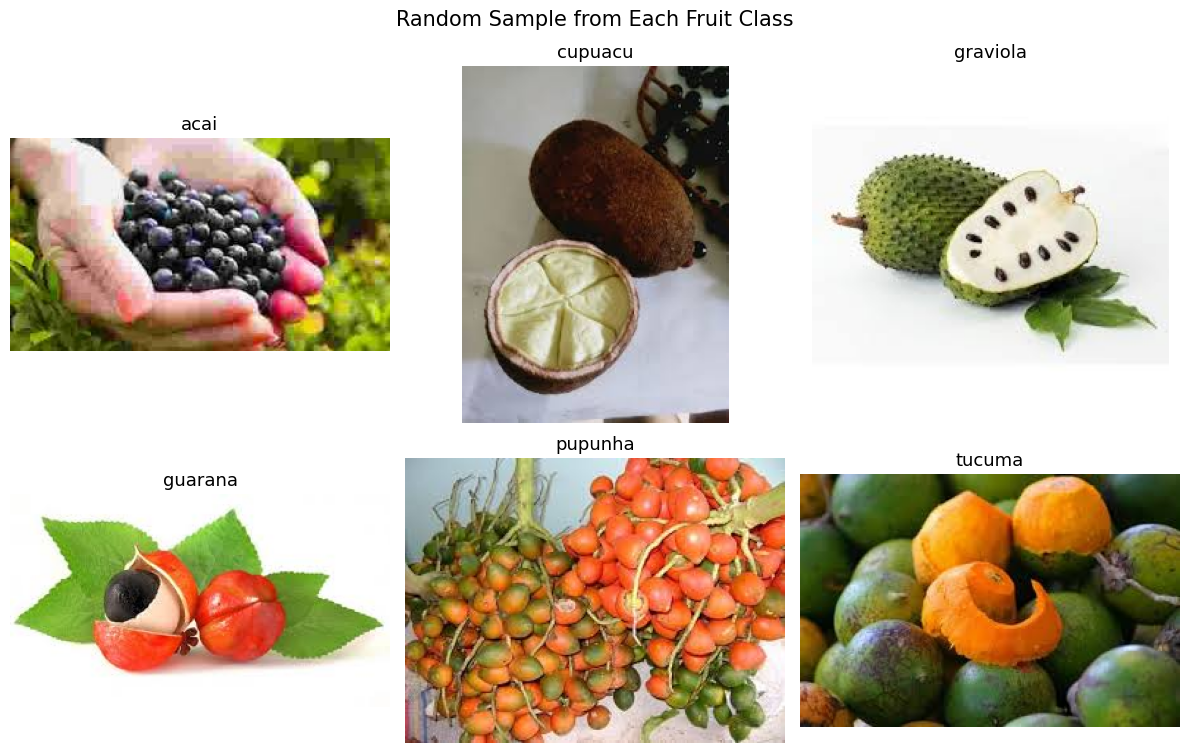

In [5]:
# Task 1.1 - Loading and visualizing one random image from each class

classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# creating a grid with 2 rows to display the images
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    random_img = random.choice(images)  # picking a random image
    img_path = os.path.join(cls_path, random_img)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=13)
    axes[i].axis('off')

# hiding any extra subplot spaces
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Random Sample from Each Fruit Class", fontsize=15)
plt.tight_layout()
plt.show()

# Observation:
# The dataset has 6 classes of Amazon fruits: acai, cupuacu, graviola, guarana, pupunha, tucuma
# The images vary in resolution, angle and background
# Some images have watermarks on them
# Each class has 15 training images which is quite small
# The fruits have different colors and textures which should help the CNN distinguish them

In [6]:
# Task 1.2 - Checking for corrupted images in the training directory

corrupted_images = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  # this verifies if the image file is not corrupted
        except (IOError, SyntaxError) as e:
            print(f"Removed corrupted image: {img_path}")
            os.remove(img_path)
            corrupted_images.append(img_path)

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


## Task 2: Loading and Preprocessing Image Data

In [7]:
# setting up image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2  # 80% for training, 20% for validation

# creating a rescaling layer to normalize pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# loading training dataset from directory
# labels are inferred from folder names automatically
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# loading validation dataset from the same directory
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# getting class names so we can use them later for predictions
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

# applying normalization to both datasets
# this scales pixel values from 0-255 to 0-1
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# also load the test dataset separately
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# normalize test dataset too
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("\nAll datasets loaded and normalized successfully")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Found 30 files belonging to 6 classes.

All datasets loaded and normalized successfully!


## Task 3: Building the CNN Model\n\nFollowing the architecture from the worksheet.

In [8]:
# building the CNN model as specified in the worksheet
model = keras.Sequential([
    # --- Convolutional Section (Feature Extraction) ---

    # Conv Layer 1: 32 filters, 3x3, same padding, stride 1, ReLU
    layers.Conv2D(32, (3, 3), padding='same', strides=(1, 1), activation='relu',
                  input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1: Max pooling 2x2, stride 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Conv Layer 2: 32 filters, 3x3, same padding, stride 1, ReLU
    layers.Conv2D(32, (3, 3), padding='same', strides=(1, 1), activation='relu'),
    # Pooling Layer 2: Max pooling 2x2, stride 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # --- Fully Connected Section (Classification) ---

    # Flatten: converts the 3D feature maps into a 1D vector
    layers.Flatten(),

    # Hidden layer 1 with 64 neurons
    layers.Dense(64, activation='relu'),
    # Hidden layer 2 with 128 neurons
    layers.Dense(128, activation='relu'),

    # Output layer: num_classes neurons with softmax activation
    # softmax gives us probability for each class
    layers.Dense(num_classes, activation='softmax')
])

# printing model summary to see the architecture and parameter counts
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [9]:
# compiling the model
# adam optimizer - adaptive learning rate, works well in most cases
# sparse_categorical_crossentropy - because our labels are integers not one-hot
# tracking accuracy as our metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
# setting up callbacks to save best model and stop early if overfitting

# ModelCheckpoint - saves the model whenever val_loss improves
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# EarlyStopping - stops training if val_loss doesnt improve for 15 epochs
# also restores the best weights automatically
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# training the model for 250 epochs as worksheet says
# early stopping will likely stop it before 250 though
print("Starting training...")
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

print(f"\nTraining finished after {len(history.history['loss'])} epochs")

Starting training...
Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.6811 - loss: 0.9244
Epoch 1: val_loss improved from None to 1.36127, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 766ms/step - accuracy: 0.6528 - loss: 0.9462 - val_accuracy: 0.5556 - val_loss: 1.3613
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8258 - loss: 0.7177
Epoch 2: val_loss improved from 1.36127 to 0.65704, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 597ms/step - accuracy: 0.8056 - loss: 0.7234 - val_accuracy: 0.8889 - val_loss: 0.6570
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8559 - loss: 0.5286
Epoch 3: val_loss did not improve from 0.65704
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 424ms/step - accuracy: 0.8333 - loss: 0.5248 - val_accuracy: 0.6667 - val_loss: 0.8443
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8895 - loss: 0.4477
Epoch 4: val_loss did not improve from 0.65704
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.9028 - loss: 0.4208 - val_accuracy: 0.6667 - val_loss: 1.0443
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8999 - loss: 0.3760
Epoch 5: val_loss improved from 0.65704 to 0.46351, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.9028 - loss: 0.3729 - val_accuracy: 0.8889 - val_loss: 0.4635
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9554 - loss: 0.2012
Epoch 6: val_loss did not improve from 0.46351
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step - accuracy: 0.9444 - loss: 0.2140 - val_accuracy: 0.7778 - val_loss: 0.5583
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 1.0000 - loss: 0.1056
Epoch 7: val_loss did not improve from 0.46351
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step - accuracy: 1.0000 - loss: 0.1063 - val_accuracy: 0.8333 - val_loss: 0.9270
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9699 - loss: 0.1342
Epoch 8: val_loss improved from 0.46351 to 0.45191, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.9722 - loss: 0.1301 - val_accuracy: 0.8333 - val_loss: 0.4519
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 1.0000 - loss: 0.0551
Epoch 9: val_loss improved from 0.45191 to 0.34905, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 667ms/step - accuracy: 1.0000 - loss: 0.0489 - val_accuracy: 0.8333 - val_loss: 0.3490
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 1.0000 - loss: 0.0506
Epoch 10: val_loss improved from 0.34905 to 0.29249, saving model to best_fruit_model.h5



Epoch 10: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 711ms/step - accuracy: 1.0000 - loss: 0.0543 - val_accuracy: 0.8889 - val_loss: 0.2925
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 1.0000 - loss: 0.0247
Epoch 11: val_loss did not improve from 0.29249
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 1.0000 - loss: 0.0223 - val_accuracy: 0.8333 - val_loss: 0.5577
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 1.0000 - loss: 0.0212
Epoch 12: val_loss did not improve from 0.29249
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 416ms/step - accuracy: 1.0000 - loss: 0.0175 - val_accuracy: 0.8333 - val_loss: 0.7211
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 1.0000 - loss: 0.0109
Epoch 13: val_loss did not improve from 0.29249
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.8333 - val_loss: 0.7347
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 1.0000 - loss: 0.0


Epoch 17: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8889 - val_loss: 0.2742
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 18: val_loss did not improve from 0.27425
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 619ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7778 - val_loss: 0.2880
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 19: val_loss did not improve from 0.27425
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 756ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.7778 - val_loss: 0.3066
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 20: val_loss did not improve from 0.27425
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 491ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8889 - val_loss: 0.3254
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 1.0000 - loss: 0.0

## Visualization: Training and Validation Curves

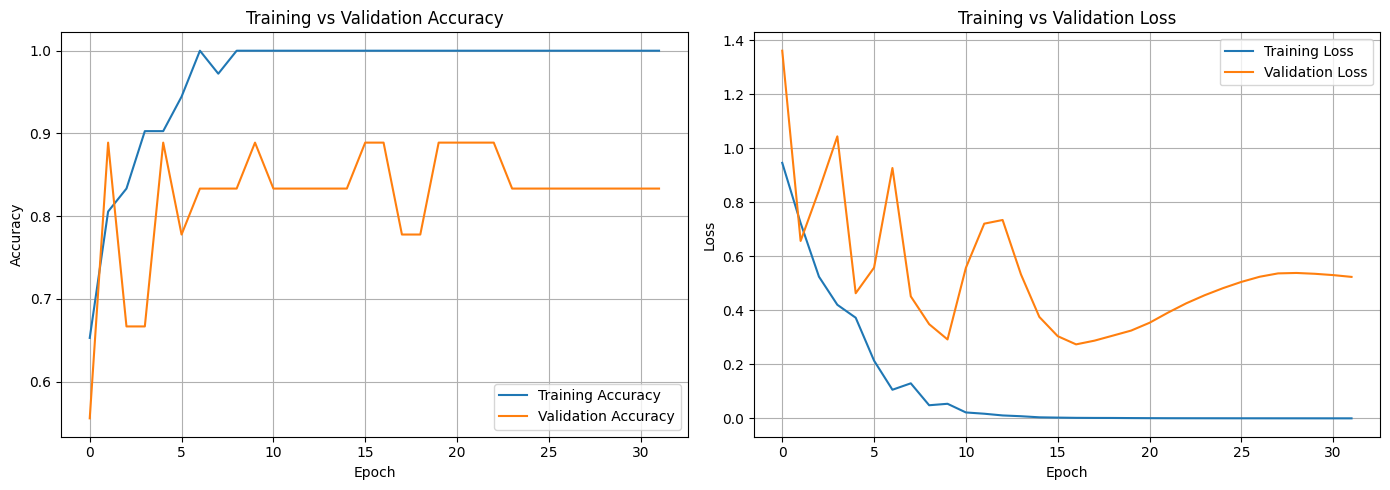

Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.8333
Final Training Loss: 0.0005
Final Validation Loss: 0.5240


In [12]:
# plotting training vs validation accuracy and loss

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# printing final values
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

## Task 5: Evaluate the Model

In [13]:
# evaluating the model on the test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6333 - loss: 1.0341

Test Loss: 1.0341
Test Accuracy: 0.6333


## Task 6: Save and Load the Model

In [14]:
# saving the trained model to .h5 file
model.save('fruit_cnn_model.h5')
print("Model saved as fruit_cnn_model.h5")

# loading the model back to verify it works
loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
print("Model loaded successfully!")

# re-evaluating with loaded model to make sure it gives same results
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}")

Model saved as fruit_cnn_model.h5
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step - accuracy: 0.6333 - loss: 1.0341

Loaded Model - Test Loss: 1.0341
Loaded Model - Test Accuracy: 0.6333


## Task 7: Predictions and Classification Report

In [15]:
# getting predictions on the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)  # converting probabilities to class labels
    y_pred.extend(predicted_labels)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# printing some sample predictions
print("Sample Predictions:")
print(f"Predicted labels: {y_pred[:10]}")
print(f"Actual labels:    {y_true[:10]}")
print(f"Predicted classes: {[class_names[i] for i in y_pred[:10]]}")
print(f"Actual classes:    {[class_names[i] for i in y_true[:10]]}")

Sample Predictions:
Predicted labels: [0 0 0 0 0 1 2 2 2 1]
Actual labels:    [0 0 0 0 0 1 1 1 1 1]
Predicted classes: ['acai', 'acai', 'acai', 'acai', 'acai', 'cupuacu', 'graviola', 'graviola', 'graviola', 'cupuacu']
Actual classes:    ['acai', 'acai', 'acai', 'acai', 'acai', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu']


In [16]:
# printing the full classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.67      0.40      0.50         5
    graviola       0.62      1.00      0.77         5
     guarana       0.50      0.40      0.44         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.63        30
   macro avg       0.64      0.63      0.61        30
weighted avg       0.64      0.63      0.61        30



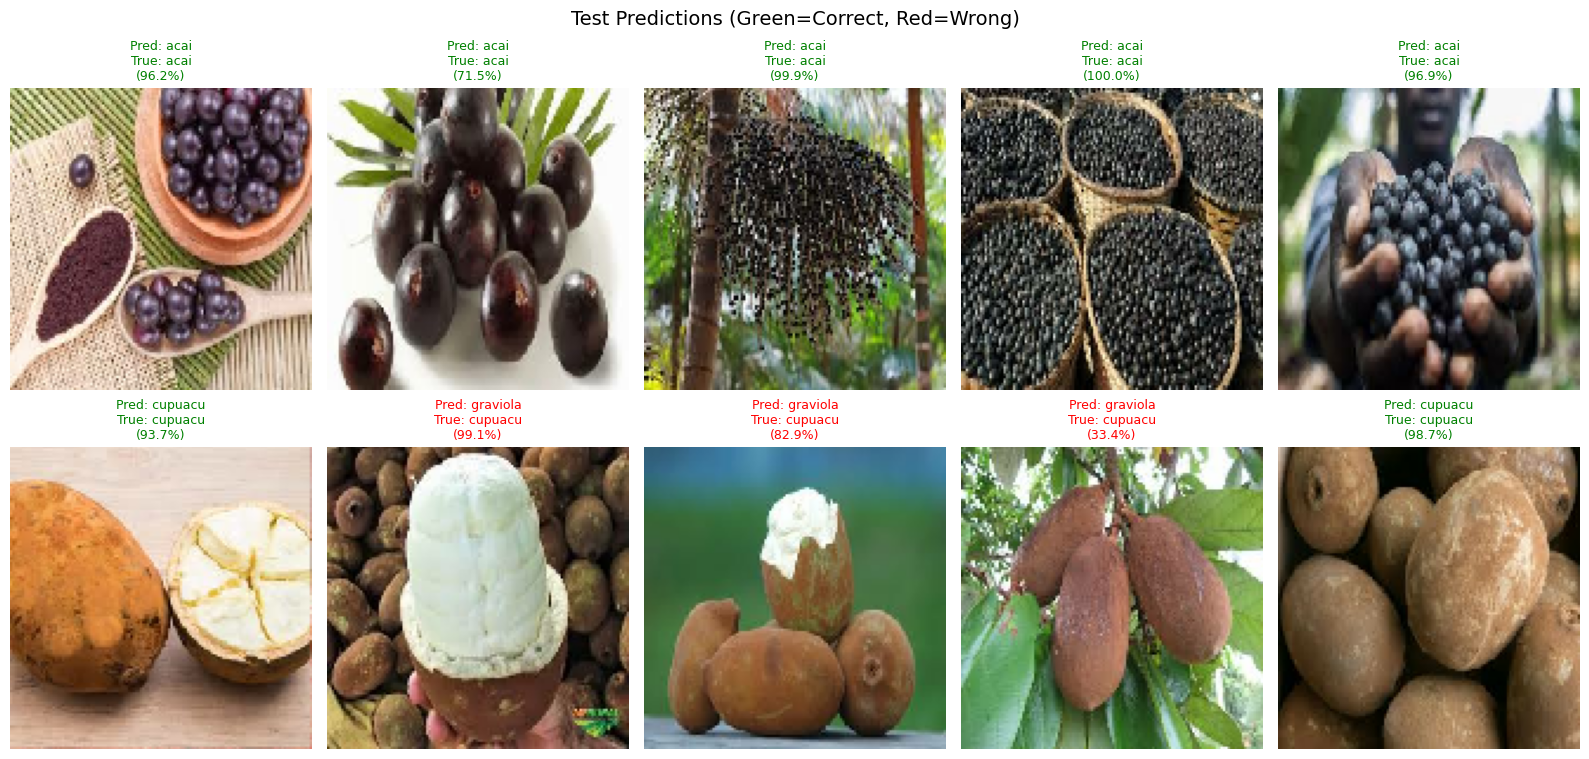

In [17]:
# showing some test predictions visually
plt.figure(figsize=(16, 8))

# getting one batch of test images
for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    num_show = min(10, len(images))

    cols = 5
    rows = (num_show + cols - 1) // cols

    for i in range(num_show):
        plt.subplot(rows, cols, i + 1)
        # displaying the image
        plt.imshow(images[i].numpy())
        pred_class = class_names[np.argmax(predictions[i])]
        true_class = class_names[labels[i].numpy()]
        confidence = np.max(predictions[i]) * 100

        # green title if correct, red if wrong
        color = 'green' if pred_class == true_class else 'red'
        plt.title(f"Pred: {pred_class}\nTrue: {true_class}\n({confidence:.1f}%)",
                  color=color, fontsize=9)
        plt.axis('off')

plt.suptitle("Test Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()